In [1]:
# notebook for testing out new TJ river flow maker...
import sys
import os
import subprocess
import shutil
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import gsw
import pickle

from datetime import datetime, timedelta, date

sys.path.append('../sdpm_py_util')
import init_funs_forecast as initfuns
import run_funs as runfuns
import util_functions as utilfuns
import river_functions as riverfuns
import ocn_funs_forecast as ocnfuns
import run_funs as runfuns
sys.path.append('/home/mspydell/models/PFM_root/PFM/driver')
import driver_functions as driverfuns
import grib2io
#from driver_run_forecast_LV1234 import driver_run_fore_LV1234
from driver_run_pfm_phm import driver_run_pfm_phm


In [5]:
ts = [datetime(2025,1,1),datetime(2025,1,2)]
t1 = datetime(2025,1,1)
print( (t1 in ts) )
print(t1)
print(ts)

True
2025-01-01 00:00:00
[datetime.datetime(2025, 1, 1, 0, 0), datetime.datetime(2025, 1, 2, 0, 0)]


In [ ]:
fn = '/dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20250315_0000_000.grb2'
g = grib2io.open(fn)
AA1 = g.select(shortName='DLWRF',level='surface')[0]
AA2 = AA1.data

# Access the .variables attribute to get a list of all unique variable short names
variable_names = g.variables

# Print the list of variables
print("Variables in the GRIB2 file:")
for var_name in variable_names:
    print(var_name)



Variables in the GRIB2 file:
4LFTX
ABSV
ACPCP
ALBDO
APCP
BMIXL
CAPE
CD
CFRZR
CICEP
CIN
CNWAT
CRAIN
CSNOW
DLWRF
DPT
DSWRF
DZDT
FRICV
GUST
HGT
HINDEX
HLCY
HPBL
ICEC
LAND
LFT X
LHTFL
LTNG
MSLET
MSTAV
PLI
POROS
PRES
PRMSL
PWAT
REFC
REFD
RETOP
RH
RLYRS
SFCR
SHTFL
SMDRY
SMREF
SNOD
SNOWC
SOILL
SOILW
SOTYP
SPFH
TCDC
TKE
TMP
TSOIL
UGRD
ULWRF
USWRF
VEG
VGRD
VGTYP
VIS
VRATE
VUCSH
VVCSH
VVEL
WEASD
WILT
unknown


: 

In [ ]:



pkl_fnm = "/scratch/PFM_Simulations/forecast_info.pkl"
t,Q = riverfuns.get_forecasted_Q_IBWC(pkl_fnm)
#fig, ax = plt.subplots()
#ax.plot(t,Q)



making river tracer dictionary
making the river discharge pickle file
using the nwm river forecast from the start time:
2025083018
to ensure that the forecast can be found on their server

river discharge data saved as pickle file
loading the river discharge pickle file...
File downloaded successfully: /home/mspydell/research/LV4_river_stuff/IBWC_Qtrje_custom.csv
1 day persistence (Qp) is  0.30962296257567035
climatology is  0.7396255346693961
using cutoff based on std NWM,  =  0.18675520130888382  m3/s
the std NWM cutoff is  1.0  m3/s
no forecasted increased flow...
1 day < 5 day, use Q_1day
plotting river discharge
QQ in rivfuns:
(123,)
[0.30962296 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296
 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296
 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296
 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296
 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296 0.30962296
 0.30962296 0.3096

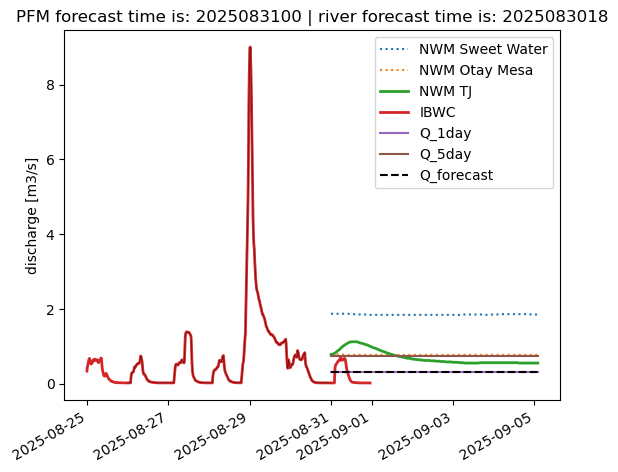

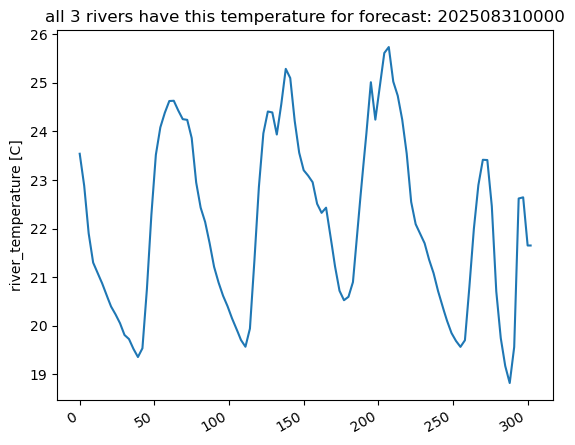

In [3]:
pkl_fnm = "/scratch/PFM_Simulations/forecast_info.pkl"
ocnfuns.mk_lv4_river_nc(pkl_fnm)


File downloaded successfully: /home/mspydell/research/LV4_river_stuff/IBWC_Qtrje_custom.csv
1 day persistence (Qp) is  0.305333404079476
4 day average of all Q<4 (super persistence, Qpp) is  0.27933046371417647
using Q = Qp exp(-t/1.5) + Qpp (1-exp(-t/1.5)) + NWM(t) - NWM(t=0)
plotting river discharge


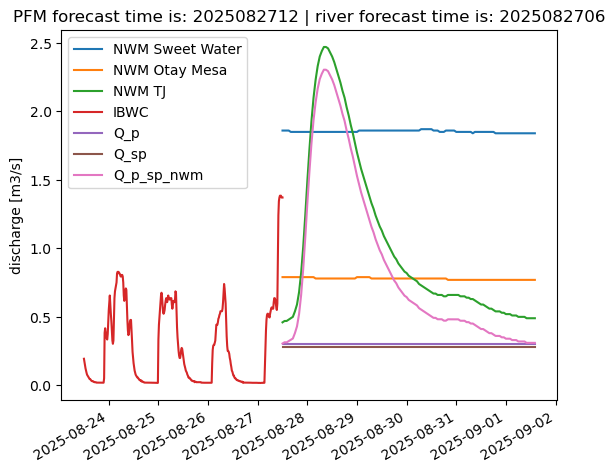

In [2]:
info_pkl="/scratch/matt/PFM_Simulations_v2/forecast_info.pkl"
t,Q = riverfuns.get_forecasted_Q_IBWC(info_pkl)


In [3]:
def get_files_with_full_path(folder_path):
    """
    Returns a list of all files in the given folder with their full paths.

    Args:
        folder_path (str): The path to the folder to scan.

    Returns:
        list: A list of strings, where each string is the full path to a file.
    """
    file_paths = []
    for entry in os.listdir(folder_path):
        full_path = os.path.join(folder_path, entry)
        if os.path.isfile(full_path):
            file_paths.append(full_path)
    return file_paths



In [4]:

# Example usage:
directory_to_scan = "/scratch/PFM_Simulations/cdip_data"  # Replace with the actual path
files_to_copy = get_files_with_full_path(directory_to_scan)
print(files_to_copy)


['/scratch/PFM_Simulations/cdip_data/cdip_1283_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_2235_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1322_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1985_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1061_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1001_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1330_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1041_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_2085_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1306_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1210_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1835_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1735_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1434_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1161_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_2385_2025082712.nc', '/scrat

In [5]:

PFM=initfuns.get_model_info(info_pkl)


archive_cdip = 1
PFM['cdip_archive_dir'] = '/dataSIO/PFM_Simulations/Archive/cdip_ncs/'
if archive_cdip == 1:
    print('copying cdip .nc files to archive...')
    dir2 = PFM['cdip_archive_dir']
    for fname in files_to_copy:
        fn_end = os.path.basename(fname)
        fn_2 = dir2 + fn_end
        try:
            shutil.copy(fname, fn_2)
            #print(f"File '{source_file}' copied successfully to '{destination_directory}'")
        except FileNotFoundError:
            print(f"Error: Source file '{fname}' not found.")
        except Exception as e:
            print(f"An error occurred: {e}")


copying cdip .nc files to archive...


In [ ]:


t1_str = '2025-08-14'
t2_str = '2025-08-22'

# if the 1st argument below is False, then we get the most recent 7 days of data
# the last time stamp is about 1-2 hours before current time. Nice!
t,Q = riverfuns.get_observed_TJriver_flow(False,t1_str,t2_str)





2025-08-22 18:00:00


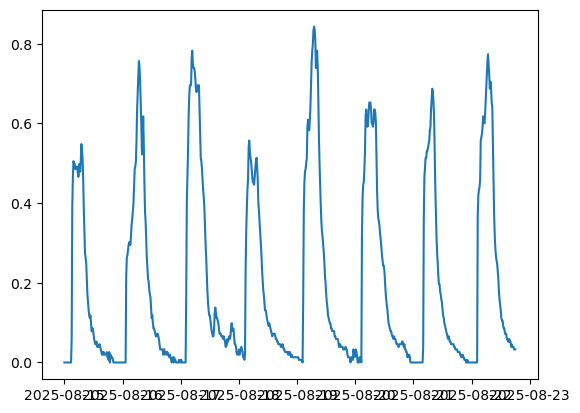

In [ ]:
fig, ax = plt.subplots()
print(t[-1])
ax.plot(t,Q)


In [9]:
file_in = '/scratch/PFM_Simulations/LV4_Forecast/Forc/river_Q.pkl'
with open(file_in,'rb') as fp:
    NWM = pickle.load(fp)

t_nwm = NWM['time']
q_nwm = NWM['discharge'][:,2]


In [38]:
#t_fore = t_nwm[0]
tf_dt = t_nwm[0] #datetime.strptime(t_fore,'%Y%m%d%H')
start_time = tf_dt - 1* timedelta(days=1)
end_time = tf_dt

# Create a boolean mask
# This directly compares datetime objects within the array
mask = (t >= start_time) & (t <= end_time)

    # Get the indices where the mask is True
indices = np.where(mask)[0]
    # take the mean over these indices
Qb1 = np.mean( Q[indices] )

mask2 = (Q<1.0)
i2 = np.where(mask2)[0]
Qb2 = np.mean( Q[i2] )

print(Qb1)
print(Qb2)

Qf_p = Qb1*np.ones(np.shape(t_nwm))
#print(np.shape(q_nwm))
#print(np.shape(Qf_p))
Qf_pnwm = Qf_p[:,0] + q_nwm - q_nwm[0]
dt = t_nwm - t_nwm[0]
dt_sec = []
for dtt in dt:
    dt_sec.append(dtt[0].total_seconds())
dt_day = np.array(dt_sec) / 3600 /24
tau_day = 1.5
alpha = np.exp(-dt_day / tau_day)
Q_new2 = Qf_p[:,0] * alpha + (1-alpha)*Qb2 
Q_new = Qf_p[:,0] * alpha + (1-alpha)*Qb2 + q_nwm - q_nwm[0]




0.16465141780116258
0.20513315114146208


2025-08-22 18:00:00


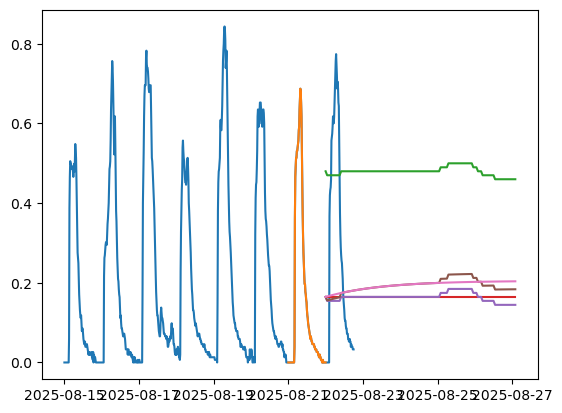

In [39]:
fig, ax = plt.subplots()
print(t[-1])
ax.plot(t,Q)
ax.plot(t[indices],Q[indices])
ax.plot(t_nwm,q_nwm)
ax.plot(t_nwm,Qf_p)
ax.plot(t_nwm,Qf_pnwm)
ax.plot(t_nwm,Q_new)
ax.plot(t_nwm,Q_new2)



In [4]:
fn = '/scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_river.nc'
ds=nc.Dataset(fn)


(123, 10, 9)
[-0.30962296 -0.30962296 -0.30962296 -0.30962296 -0.30962296 -0.30962296
 -0.30962296 -0.30962296 -0.30962296]


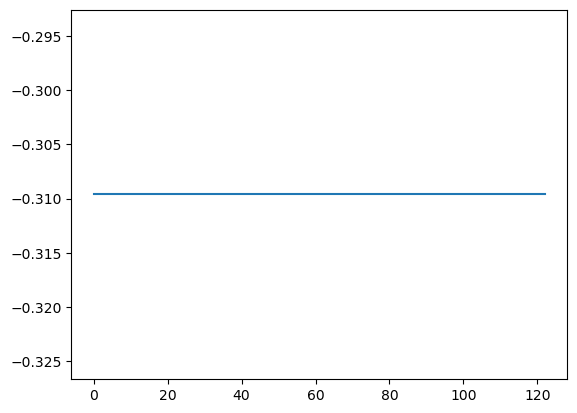

In [6]:
fig, ax = plt.subplots()
dye_02 = ds.variables['river_dye_02'][:]
Qtj = 5 * ds.variables['river_transport'][:,0]
print(np.shape(dye_02))
print(Qtj[1:10])
#ax.plot(dye_02[:,-1,0])
ax.plot(Qtj)


In [4]:

yyyymmdd = '20250831'
info_pkl="/scratch/matt/PFM_Simulations_v2/forecast_info.pkl"
ocnfuns.get_hycom_data_1hr_v2(yyyymmdd,info_pkl)

in get_hycom_data_1hr_v2
attempting to get a total of 453 hycom nc files ...
just before loop
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom files... done.
getting <=10 hycom fil

In [ ]:
#pkl_fnm="/scratch/matt/PFM_Simulations_v2/forecast_info.pkl"
pkl_fnm = "/scratch/PFM_Simulations/forecast_info.pkl"
runfuns.run_slurm_LV4(pkl_fnm, 'fore')

print('making web.nc file...')
ret = utilfuns.make_web_nc_file(pkl_fnm)
print('...done making web nc file: ' + str(ret.returncode) + ' (0=good)')  

print('copying and moving LV4 atm and river nc files to Archive...')
utilfuns.copy_mv_nc_file('atm','lv4',pkl_fnm)
utilfuns.copy_mv_nc_file('river','lv4',pkl_fnm)
print('...done')

#lvs_to_plt = ['LV1','LV2','LV3','LV4','LV4dye']
lvs_to_plt = ['LV4','LV4dye']
print('making history and dye plots for levels...')
print(lvs_to_plt)
utilfuns.make_simulation_plots(lvs_to_plt,pkl_fnm)



starting the background process that looks for modified swan restart files
we check for modified files every 144 s (wall time)
run_slurm_LV4: current directory is now:  /scratch/PFM_Simulations/LV4_Forecast/Run
terminated the swan restart file check and move subprocess.
CompletedProcess(args=['sbatch', '--wait', 'LV4_SLURM.sb'], returncode=0, stdout=b'Submitted batch job 2869\n', stderr=b'')
run_slurm_LV4: run command:  ['sbatch', '--wait', 'LV4_SLURM.sb']
subprocess slurm ran correctly? 0 (0=yes)
making web.nc file...
moving and copying /scratch/PFM_Simulations/LV4_Forecast/His/web_data_2025090100.nc  file
to  /dataSIO/PFM_Simulations/Archive/for_web/  and  /dataSIO/PFM_Simulations/Archive/web/
Deleted: /dataSIO/PFM_Simulations/Archive/for_web/web_data_latest.nc
The file '/scratch/PFM_Simulations/LV4_Forecast/His/web_data_2025090100.nc' exists.
copying web.nc to /dataSIO/... now...
renaming  /dataSIO/PFM_Simulations/Archive/for_web/web_data_2025090100.nc  to 
/dataSIO/PFM_Simulations/

In [ ]:
os.chdir('../sdpm_py_util')
aa = 'vrm'
pkl_fnm="/scratch/matt/PFM_Simulations_v2/forecast_info.pkl"
MI = initfuns.get_model_info(pkl_fnm)
fname_in = MI['lv1_forc_dir'] + '/' + MI['lv1_ocn_tmp_pckl_file']
cmd_list = ['python','-W','ignore','ocn_funs_forecast.py','make_tmp_hy_on_rom_pckl_files_1hrzeta',fname_in,aa,pkl_fnm]
ret1 = subprocess.run(cmd_list )     



In [6]:
pkl_fnm="/scratch/matt/PFM_Simulations_v2/forecast_info.pkl"
cmd_list = ['python','-W','ignore','ocn_funs_forecast.py','make_all_tmp_pckl_ocnR_files_1hrzeta',pkl_fnm]
os.chdir('../sdpm_py_util')
ret1 = subprocess.run(cmd_list)     



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
the urm pickle file was not made correctly
CompletedProcess(args=['python', '-W', 'ignore', 'ocn_funs_forecast.py', 'make_tmp_hy_on_rom_pckl_files_1hrzeta', '/scratch/PFM_Simulations/LV1_Forecast/Forc/hycom_tmp_pckl_file.pkl', 'urm', '/scratch/matt/PFM_Simulations_v2/forecast_info.pkl'], returncode=-9)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
the vrm pickle file was not made correctly
CompletedProcess(args=['python', '-W', 'ignore', 'ocn_funs_forecast.py', 'make_tmp_hy_on_rom_pckl_files_1hrzeta', '/scratch/PFM_Simulations/LV1_Forecast/Forc/hycom_tmp_pckl_file.pkl', 'vrm', '/scratch/matt/PFM_Simulations_v2/forecast_info.pkl'], returncode=-9)
...done. 
at least one of the ocnR pickle files were not made correctly
